# Traffic and Vehicle Behaviour

In [1]:
# Importing necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LinearRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.model_selection import cross_val_score
import joblib

In [2]:
# Load the dataset
df = pd.read_csv('dt.csv')
df.head() # tail()

,City,Vehicle Type,Weather,Economic Condition,Day Of Week,Hour Of Day,Speed,Is Peak Hour,Random Event Occurred,Energy Consumption,Traffic Density
0,New York,Car,Sunny,Stable,Monday,8,60,True,False,50,Medium
1,New York,Car,Sunny,Stable,Monday,12,55,True,False,48,High
2,New York,Bus,Rainy,Stable,Tuesday,16,40,False,False,60,High
3,Los Angeles,Car,Cloudy,Stable,Wednesday,10,65,False,False,45,Low
4,Los Angeles,Car,Sunny,Stable,Thursday,18,50,True,True,55,Medium


In [3]:
df.head(10)

,City,Vehicle Type,Weather,Economic Condition,Day Of Week,Hour Of Day,Speed,Is Peak Hour,Random Event Occurred,Energy Consumption,Traffic Density
0,New York,Car,Sunny,Stable,Monday,8,60,True,False,50,Medium
1,New York,Car,Sunny,Stable,Monday,12,55,True,False,48,High
2,New York,Bus,Rainy,Stable,Tuesday,16,40,False,False,60,High
3,Los Angeles,Car,Cloudy,Stable,Wednesday,10,65,False,False,45,Low
4,Los Angeles,Car,Sunny,Stable,Thursday,18,50,True,True,55,Medium
5,Los Angeles,Truck,Rainy,Declining,Friday,14,35,False,False,70,High
6,Chicago,Car,Snowy,Stable,Saturday,9,45,False,False,42,Medium
7,Chicago,Car,Sunny,Growing,Sunday,13,55,True,False,47,Low
8,Chicago,Bus,Cloudy,Growing,Monday,17,30,True,False,65,High
9,New York,Car,Sunny,Stable,Monday,8,58,True,False,52,Medium


In [4]:
# Explore and understand the data
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 36 entries, 0 to 35
Data columns (total 11 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   City                   36 non-null     object
 1   Vehicle Type           36 non-null     object
 2   Weather                36 non-null     object
 3   Economic Condition     36 non-null     object
 4   Day Of Week            36 non-null     object
 5   Hour Of Day            36 non-null     int64 
 6   Speed                  36 non-null     int64 
 7   Is Peak Hour           36 non-null     bool  
 8   Random Event Occurred  36 non-null     bool  
 9   Energy Consumption     36 non-null     int64 
 10  Traffic Density        36 non-null     object
dtypes: bool(2), int64(3), object(6)
memory usage: 2.7+ KB


In [5]:
# Statistics of the dataset
df.describe()

,Hour Of Day,Speed,Energy Consumption
count,36.000000,36.000000,36.000000
mean,13.000000,47.888889,52.666667
std,3.414256,10.609370,8.538986
min,8.000000,28.000000,40.000000
25%,10.000000,39.500000,46.750000
50%,13.000000,49.500000,50.000000
75%,16.000000,56.250000,59.250000
max,18.000000,65.000000,70.000000


In [7]:
# Find the missing value
df.isnull().sum()

City                     0
Vehicle Type             0
Weather                  0
Economic Condition       0
Day Of Week              0
Hour Of Day              0
Speed                    0
Is Peak Hour             0
Random Event Occurred    0
Energy Consumption       0
Traffic Density          0
dtype: int64

In [8]:
# Rows and Cols
df.shape

(36, 11)

In [10]:
# Cols
df.columns

Index(['City', 'Vehicle Type', 'Weather', 'Economic Condition', 'Day Of Week',
       'Hour Of Day', 'Speed', 'Is Peak Hour', 'Random Event Occurred',
       'Energy Consumption', 'Traffic Density'],
      dtype='object')

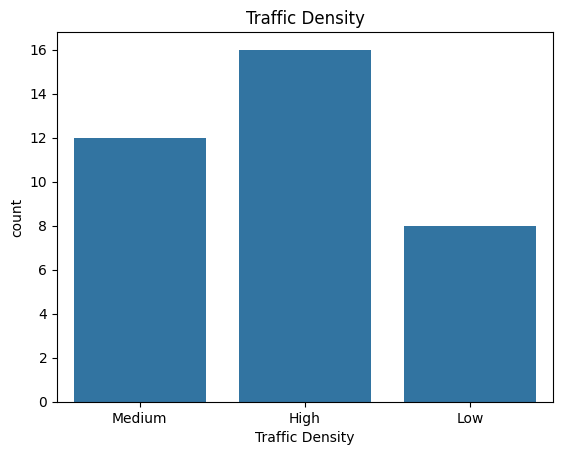

In [12]:
# Univariate Analysis
sns.countplot(x='Traffic Density', data=df)
plt.title('Traffic Density')
plt.show()

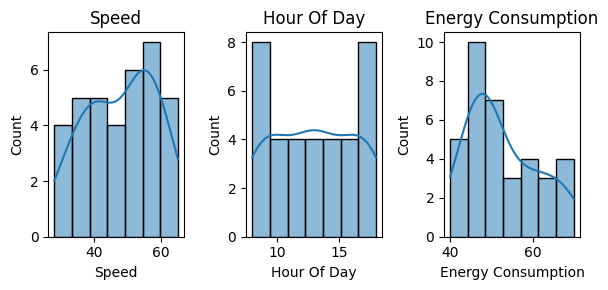

In [13]:
num_cols = ['Speed', 'Hour Of Day', 'Energy Consumption']
fig, axes = plt.subplots(1, 3, figsize=(6, 3))
for ax, col in zip(axes, num_cols):
    sns.histplot(df[col], kde=True, ax = ax)
    ax.set_title(col)
plt.tight_layout()
plt.show()

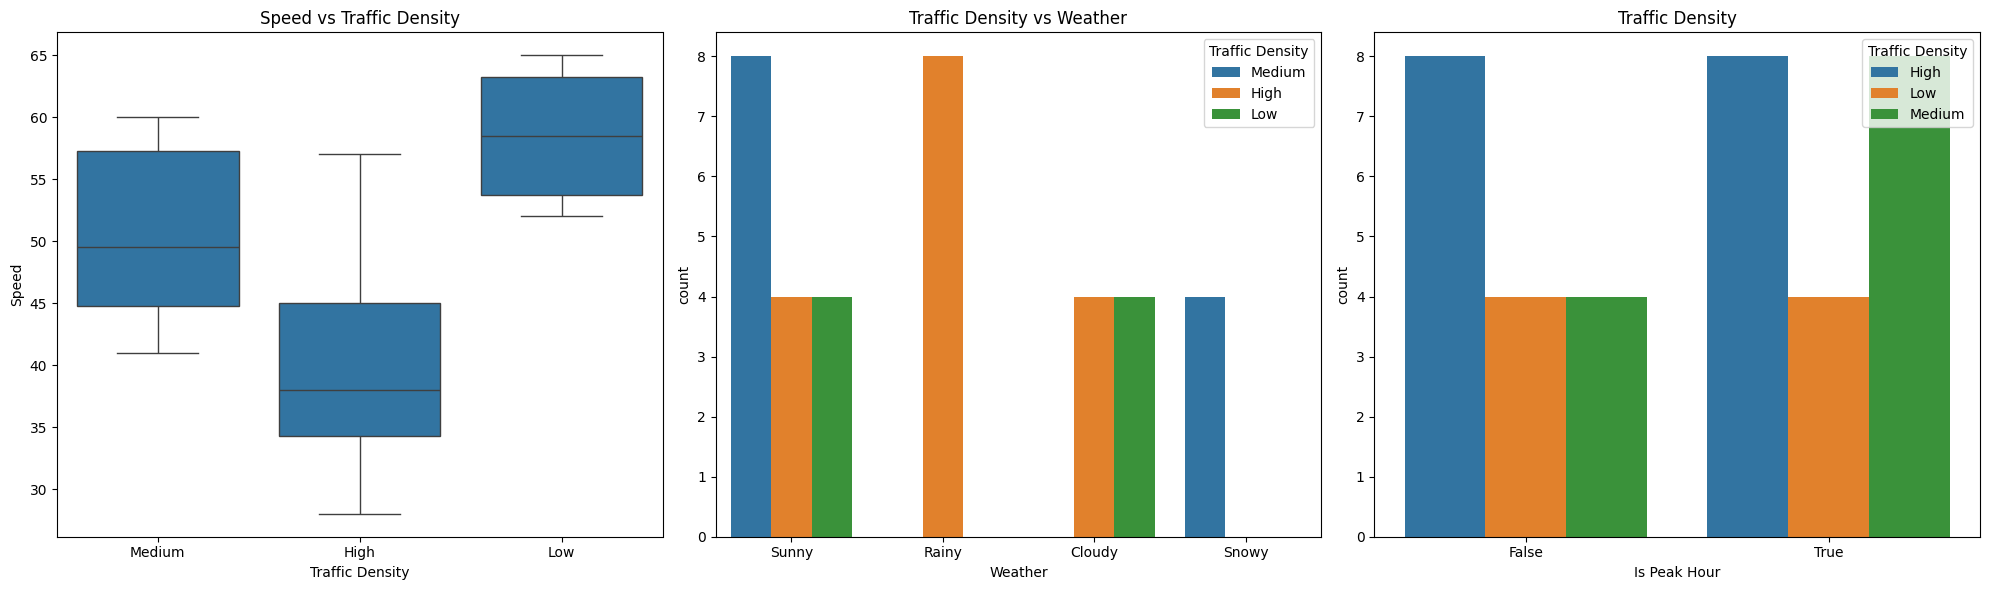

In [14]:
# Bivariate analysis
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
sns.boxplot(x = 'Traffic Density', y = 'Speed', data = df, ax=axes[0]).set_title('Speed vs Traffic Density')
sns.countplot(x = 'Weather', hue = 'Traffic Density', data = df, ax=axes[1]).set_title('Traffic Density vs Weather')
sns.countplot(x = 'Is Peak Hour', hue = 'Traffic Density', data = df, ax=axes[2]).set_title('Traffic Density')
plt.tight_layout()
plt.show()

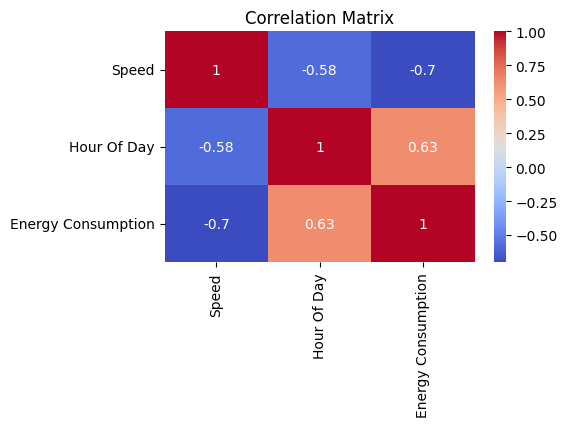

In [15]:
# Correlation matrix for numerical features
plt.figure(figsize=(5,3))
sns.heatmap(df[num_cols].corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()

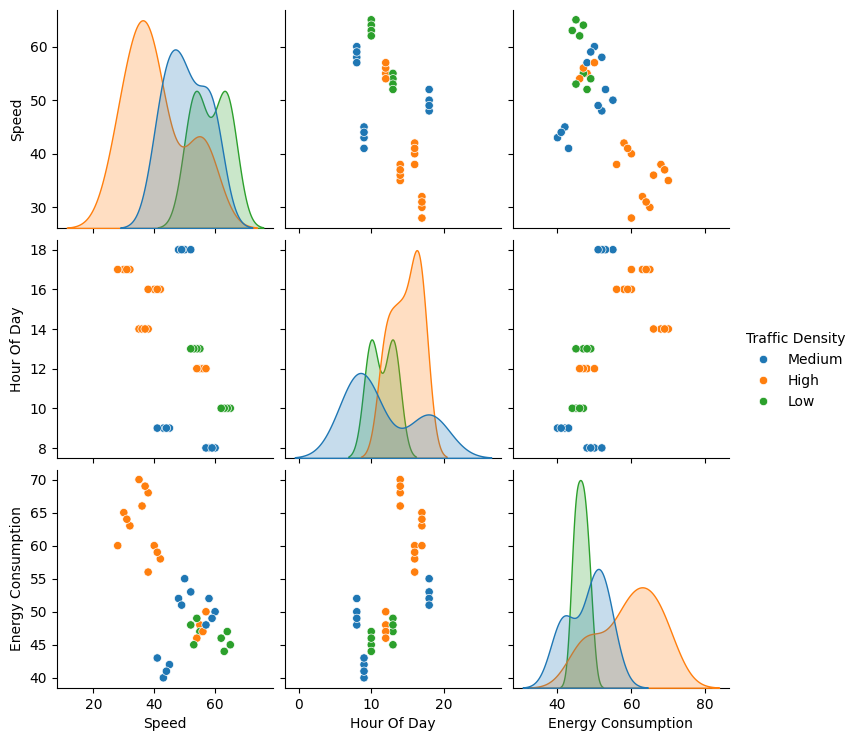

In [16]:
# Pairplot for numerical features colored by Traffic Density
sns.pairplot(df, vars=num_cols, hue='Traffic Density')
plt.show()

In [17]:
df.columns

Index(['City', 'Vehicle Type', 'Weather', 'Economic Condition', 'Day Of Week',
       'Hour Of Day', 'Speed', 'Is Peak Hour', 'Random Event Occurred',
       'Energy Consumption', 'Traffic Density'],
      dtype='object')

In [19]:
# Data Preprocessing
le = LabelEncoder()
categorical_cols = ['City', 'Vehicle Type', 'Weather', 'Economic Condition', 'Day Of Week', 'Traffic Density']
for col in categorical_cols:
    df[col] = le.fit_transform(df[col])

In [20]:
# Convert boolean to int
df['Is Peak Hour'] = df['Is Peak Hour'].astype(int)
df['Random Event Occurred'] = df['Random Event Occurred'].astype(int)

In [21]:
# Feature and target selection
X = df.drop('Traffic Density', axis = 1)
y = df['Traffic Density']

In [22]:
# Split data into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [23]:
X_train.shape

(28, 10)

In [24]:
X_test.shape

(8, 10)

In [25]:
# Scale num features
scaler = StandardScaler()
X_train[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test[num_cols] = scaler.transform(X_test[num_cols])

In [27]:
X_train

,City,Vehicle Type,Weather,Economic Condition,Day Of Week,Hour Of Day,Speed,Is Peak Hour,Random Event Occurred,Energy Consumption
8,0,0,0,1,1,1.328868,-1.817243,1,0,1.361885
17,0,0,0,1,1,1.328868,-1.605672,1,0,1.136247
9,2,1,3,2,1,-1.438692,1.144750,1,0,-0.104760
34,0,1,3,1,3,0.098841,0.510037,1,0,-0.556036
0,2,1,3,2,1,-1.438692,1.356321,1,0,-0.330398
4,1,1,3,2,4,1.636375,0.298466,1,1,0.233696
29,2,0,1,2,5,1.021362,-0.653603,0,0,0.684972
15,0,1,2,2,2,-1.131185,-0.442032,0,0,-1.458587
19,2,1,3,2,1,-0.208665,0.721608,1,0,-0.781674
5,1,2,1,0,0,0.406348,-1.288316,0,0,1.925979
